# XGBoost Implementation for Delivery Time Prediction  
## Google Colab Ready Notebook

### Business Use Case
In logistics, e-commerce, and supply chain operations, predicting **delivery time** is important for:
- customer promise dates
- route planning
- warehouse scheduling
- carrier performance monitoring
- reducing delays and improving customer satisfaction

In this notebook, we build an **XGBoost Regressor** to predict the number of days required to deliver a shipment.

### Target Variable
- `delivery_time_days` → a continuous numeric value

### Why XGBoost?
XGBoost is excellent for regression problems on structured data because it:
- handles non-linear patterns well
- performs strongly on tabular business datasets
- captures interactions between features
- often gives high prediction accuracy

## What This Notebook Covers

- generate a realistic delivery operations dataset
- understand delivery-time prediction as a regression problem
- preprocess categorical and numeric features
- train an XGBoost regression model
- evaluate performance
- interpret feature importance
- predict delivery time for a new shipment
- save the trained model

This notebook is fully executable in **Google Colab**.

In [2]:
# Install XGBoost in Colab if needed
!pip install -q xgboost

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

## Step 1: Create a Realistic Delivery Dataset

For learning purposes, we generate a **business-like logistics dataset** with realistic shipment attributes.

### Input Features
- distance in km
- shipping mode
- package weight
- warehouse processing time
- traffic level
- weather condition
- carrier type
- order priority
- weekend dispatch
- destination zone
- warehouse load
- fuel cost index

### Output
- actual delivery time in days

In [4]:
np.random.seed(42)
n = 3000

distance_km = np.random.randint(20, 2500, n)
package_weight_kg = np.round(np.random.uniform(0.5, 40.0, n), 2)
warehouse_processing_hours = np.round(np.random.uniform(1, 36, n), 1)
warehouse_load_pct = np.round(np.random.uniform(30, 100, n), 1)
fuel_cost_index = np.round(np.random.uniform(80, 140, n), 1)

shipping_mode = np.random.choice(["Standard", "Express", "Same Day"], n, p=[0.60, 0.30, 0.10])
traffic_level = np.random.choice(["Low", "Medium", "High"], n, p=[0.25, 0.45, 0.30])
weather_condition = np.random.choice(["Clear", "Rain", "Storm"], n, p=[0.65, 0.25, 0.10])
carrier_type = np.random.choice(["Carrier_A", "Carrier_B", "Carrier_C"], n)
order_priority = np.random.choice(["Low", "Normal", "High", "Urgent"], n, p=[0.15, 0.50, 0.25, 0.10])
weekend_dispatch = np.random.choice(["No", "Yes"], n, p=[0.75, 0.25])
destination_zone = np.random.choice(["Urban", "Suburban", "Rural"], n, p=[0.45, 0.35, 0.20])

df = pd.DataFrame({
    "distance_km": distance_km,
    "package_weight_kg": package_weight_kg,
    "warehouse_processing_hours": warehouse_processing_hours,
    "warehouse_load_pct": warehouse_load_pct,
    "fuel_cost_index": fuel_cost_index,
    "shipping_mode": shipping_mode,
    "traffic_level": traffic_level,
    "weather_condition": weather_condition,
    "carrier_type": carrier_type,
    "order_priority": order_priority,
    "weekend_dispatch": weekend_dispatch,
    "destination_zone": destination_zone
})

# Construct realistic delivery time logic with noise
base_days = distance_km / 500
weight_effect = package_weight_kg * 0.02
processing_effect = warehouse_processing_hours / 24
warehouse_load_effect = warehouse_load_pct / 200

shipping_effect = np.select(
    [
        shipping_mode == "Same Day",
        shipping_mode == "Express",
        shipping_mode == "Standard"
    ],
    [
        -1.5,
        -0.7,
        0.5
    ],
    default=0.0
)

traffic_effect = np.select(
    [traffic_level == "Low", traffic_level == "Medium", traffic_level == "High"],
    [0.0, 0.5, 1.2],
    default=0.0
)

weather_effect = np.select(
    [weather_condition == "Clear", weather_condition == "Rain", weather_condition == "Storm"],
    [0.0, 0.8, 2.0],
    default=0.0
)

priority_effect = np.select(
    [order_priority == "Urgent", order_priority == "High", order_priority == "Normal", order_priority == "Low"],
    [-1.0, -0.5, 0.0, 0.6],
    default=0.0
)

weekend_effect = np.where(weekend_dispatch == "Yes", 0.6, 0.0)

zone_effect = np.select(
    [destination_zone == "Urban", destination_zone == "Suburban", destination_zone == "Rural"],
    [0.0, 0.4, 1.0],
    default=0.0
)

carrier_effect = np.select(
    [carrier_type == "Carrier_A", carrier_type == "Carrier_B", carrier_type == "Carrier_C"],
    [0.0, 0.3, 0.6],
    default=0.0
)

fuel_effect = (fuel_cost_index - 100) / 50 * 0.1
noise = np.random.normal(0, 0.6, n)

delivery_time_days = (
    base_days
    + weight_effect
    + processing_effect
    + warehouse_load_effect
    + shipping_effect
    + traffic_effect
    + weather_effect
    + priority_effect
    + weekend_effect
    + zone_effect
    + carrier_effect
    + fuel_effect
    + noise
)

delivery_time_days = np.round(np.clip(delivery_time_days, 0.5, None), 2)
df["delivery_time_days"] = delivery_time_days

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (3000, 13)


,distance_km,package_weight_kg,warehouse_processing_hours,warehouse_load_pct,fuel_cost_index,shipping_mode,traffic_level,weather_condition,carrier_type,order_priority,weekend_dispatch,destination_zone,delivery_time_days
0,880,35.15,11.3,47.4,103.3,Standard,High,Clear,Carrier_B,Normal,No,Suburban,4.76
1,1314,37.79,16.6,94.9,113.5,Standard,High,Rain,Carrier_B,High,No,Suburban,7.63
2,1150,6.38,26.4,95.2,114.6,Standard,Low,Clear,Carrier_C,Normal,Yes,Rural,7.91
3,1115,18.78,25.3,80.4,89.9,Standard,High,Rain,Carrier_A,Normal,No,Urban,6.69
4,1658,39.25,35.6,83.6,104.2,Standard,Medium,Clear,Carrier_A,High,No,Urban,6.90


## Step 2: Explore the Dataset

In [5]:
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   distance_km                 3000 non-null   int64  
 1   package_weight_kg           3000 non-null   float64
 2   warehouse_processing_hours  3000 non-null   float64
 3   warehouse_load_pct          3000 non-null   float64
 4   fuel_cost_index             3000 non-null   float64
 5   shipping_mode               3000 non-null   object 
 6   traffic_level               3000 non-null   object 
 7   weather_condition           3000 non-null   object 
 8   carrier_type                3000 non-null   object 
 9   order_priority              3000 non-null   object 
 10  weekend_dispatch            3000 non-null   object 
 11  destination_zone            3000 non-null   object 
 12  delivery_time_days          3000 non-null   float64
dtypes: float64(5), int64(1), object(7

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
distance_km,3000.0,NaN,NaN,NaN,1270.896,708.281382,20.0,675.25,1272.0,1883.0,2499.0
package_weight_kg,3000.0,NaN,NaN,NaN,20.060513,11.372349,0.5,10.3175,19.79,29.82,39.98
warehouse_processing_hours,3000.0,NaN,NaN,NaN,18.145333,10.077106,1.0,9.4,18.0,26.8,36.0
warehouse_load_pct,3000.0,NaN,NaN,NaN,65.055767,19.901017,30.0,48.1,64.9,82.025,100.0
fuel_cost_index,3000.0,NaN,NaN,NaN,109.815833,17.676257,80.0,94.2,109.3,125.7,140.0
shipping_mode,3000,3,Standard,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN
traffic_level,3000,3,Medium,1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather_condition,3000,3,Clear,1869,NaN,NaN,NaN,NaN,NaN,NaN,NaN
carrier_type,3000,3,Carrier_C,1028,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_priority,3000,4,Normal,1524,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 3: Visualize the Target Variable

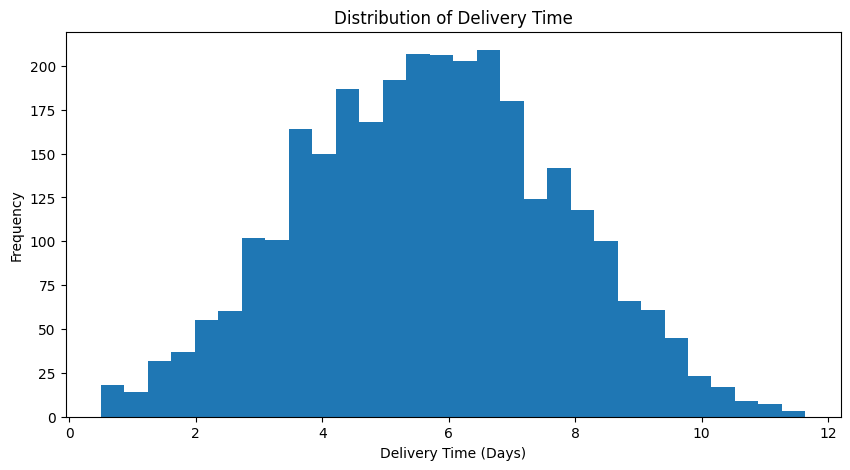

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(df["delivery_time_days"], bins=30)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Frequency")
plt.show()

## Step 4: Define Features and Target

We separate:
- `X` = input variables
- `y` = delivery time in days

In [7]:
X = df.drop(columns=["delivery_time_days"])
y = df["delivery_time_days"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (3000, 12)
Target shape: (3000,)


## Step 5: Identify Numeric and Categorical Columns

In [8]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("\nNumeric columns:", numeric_cols)

Categorical columns: ['shipping_mode', 'traffic_level', 'weather_condition', 'carrier_type', 'order_priority', 'weekend_dispatch', 'destination_zone']

Numeric columns: ['distance_km', 'package_weight_kg', 'warehouse_processing_hours', 'warehouse_load_pct', 'fuel_cost_index']


## Step 6: Build the Preprocessing Pipeline

### Numeric columns
- fill missing values with median

### Categorical columns
- fill missing values with most frequent value
- one-hot encode the categories

This converts all model input into a numeric format XGBoost can learn from.

In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

## Step 7: Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2400, 12)
X_test : (600, 12)
y_train: (2400,)
y_test : (600,)


## Step 8: Create the XGBoost Regression Model

We use `XGBRegressor` because delivery time is a **continuous numeric prediction problem**.

In [11]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42
)

## Step 9: Combine Preprocessing and Model into One Pipeline

In [12]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", xgb_model)
])

model.fit(X_train, y_train)
print("Model training completed successfully.")

Model training completed successfully.


## Step 10: Make Predictions

In [13]:
y_pred = model.predict(X_test)

pred_df = pd.DataFrame({
    "Actual_Delivery_Time": y_test.values,
    "Predicted_Delivery_Time": y_pred
})

pred_df.head(10)

,Actual_Delivery_Time,Predicted_Delivery_Time
0,0.96,1.864758
1,4.51,4.272829
2,7.33,6.952161
3,6.16,5.716441
4,4.82,4.890629
5,6.75,6.405890
6,7.41,6.286827
7,3.87,3.249253
8,2.85,2.252489
9,6.25,6.052841


## Step 11: Evaluate Model Performance

We calculate:
- **MAE** = average absolute error
- **RMSE** = root mean squared error
- **R²** = proportion of variance explained by the model

In [15]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.3f} days")
print(f"RMSE : {rmse:.3f} days")
print(f"R²   : {r2:.4f}")

MAE  : 0.546 days
RMSE : 0.696 days
R²   : 0.8848


## Step 12: Plot Actual vs Predicted Delivery Time

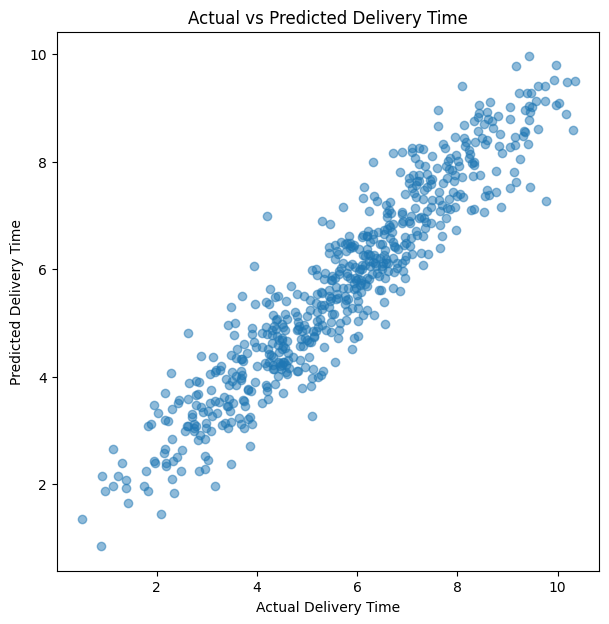

In [16]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")
plt.show()

## Step 13: Residual Analysis

Residual = Actual - Predicted

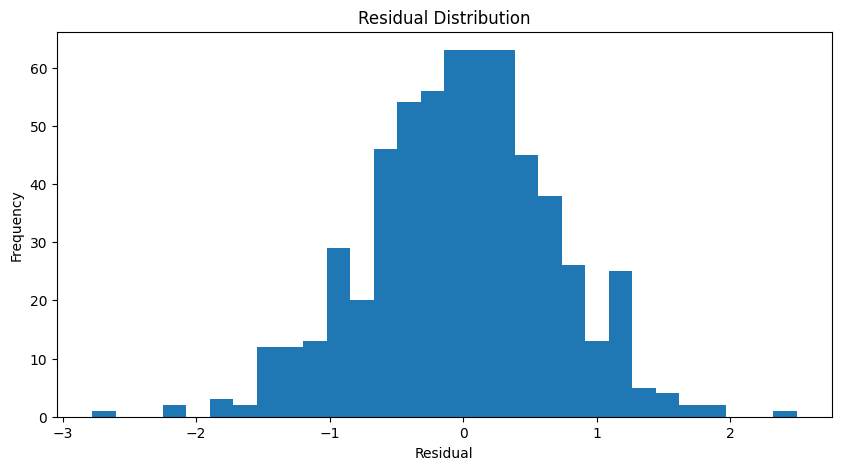

In [17]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

## Step 14: Feature Importance

This shows which shipment factors most influence delivery time prediction.

In [18]:
fitted_preprocessor = model.named_steps["preprocessor"]
fitted_regressor = model.named_steps["regressor"]

feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_regressor.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(15)

,Feature,Importance
7,cat__shipping_mode_Standard,0.209067
0,num__distance_km,0.109758
11,cat__weather_condition_Clear,0.100222
13,cat__weather_condition_Storm,0.091609
8,cat__traffic_level_High,0.048324
23,cat__destination_zone_Rural,0.046712
18,cat__order_priority_Low,0.039726
9,cat__traffic_level_Low,0.038255
20,cat__order_priority_Urgent,0.036351
12,cat__weather_condition_Rain,0.033735


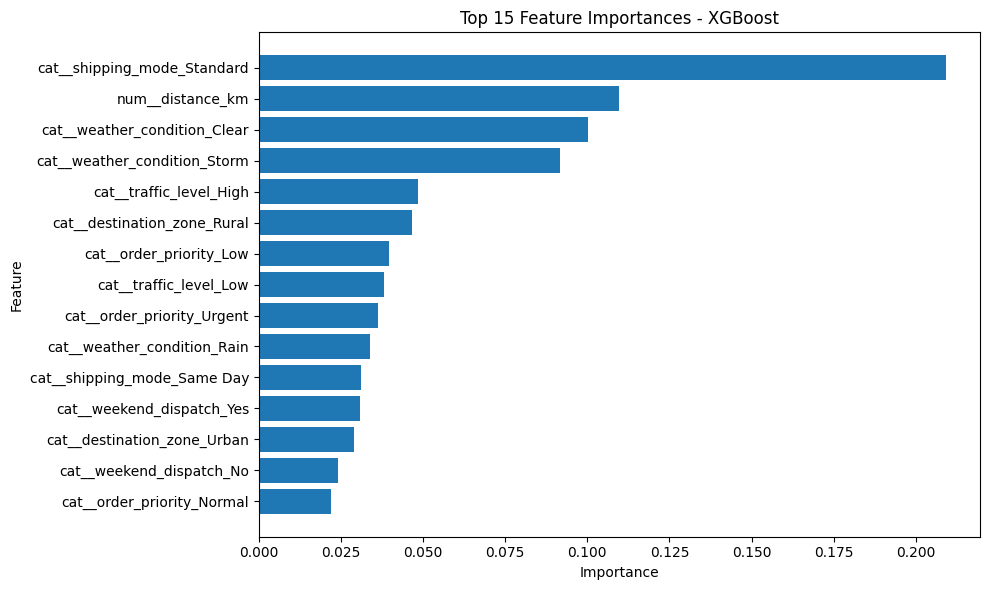

In [19]:
top_n = 15
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - XGBoost")
plt.tight_layout()
plt.show()

## Step 15: Predict Delivery Time for a New Shipment

Now we test the model on a new shipment example.

In [20]:
new_shipment = pd.DataFrame([{
    "distance_km": 850,
    "package_weight_kg": 8.5,
    "warehouse_processing_hours": 10,
    "warehouse_load_pct": 72,
    "fuel_cost_index": 112,
    "shipping_mode": "Express",
    "traffic_level": "High",
    "weather_condition": "Rain",
    "carrier_type": "Carrier_B",
    "order_priority": "High",
    "weekend_dispatch": "No",
    "destination_zone": "Suburban"
}])

predicted_delivery_time = model.predict(new_shipment)[0]

print(f"Predicted delivery time: {predicted_delivery_time:.2f} days")

Predicted delivery time: 3.99 days


## Step 16: Business Interpretation

### Example use in business
If the predicted delivery time is high, the company can:
- change carrier
- prioritize warehouse processing
- switch to express mode
- notify the customer early
- re-route shipments when traffic or weather risk is high

### Why this matters
A delivery time prediction model helps:
- improve customer satisfaction
- reduce missed promise dates
- optimize transport decisions
- monitor logistics performance

## Step 17: Save the Trained Model

In [21]:
joblib.dump(model, "xgboost_delivery_time_model.pkl")
print("Model saved as xgboost_delivery_time_model.pkl")

Model saved as xgboost_delivery_time_model.pkl


## Step 18: Export Prediction Results

In [22]:
pred_df.to_csv("delivery_time_predictions.csv", index=False)
print("Prediction file saved as delivery_time_predictions.csv")

Prediction file saved as delivery_time_predictions.csv


## Final Conclusion

We successfully implemented **XGBoost Regression** for a real-world **delivery time prediction** use case.

### What this notebook demonstrates
- delivery time as a regression problem
- preprocessing of structured logistics data
- model training using XGBoost
- performance evaluation
- feature importance
- new shipment prediction
- model export

This notebook is suitable for:
- Google Colab
- machine learning learning exercises
- logistics analytics demos
- academic or business presentations